# Exercícios de Outliers com a Regra do IQR

## Integrantes

- Kauan Fonseca do Vale
- João Pedro Carvalho dos Santos
- João Gabriel Oliveira Garcia
- Gabriel Oliveira
- Thiago Martins de Carvalho

Neste notebook resolvemos os 11 exercícios da lista sobre quartis, Intervalo Interquartil (IQR), limites inferior e superior, identificação de candidatos a outlier e aplicação da técnica com NumPy, Pandas e Matplotlib.

## Observação importante

Os valores de Q1 e Q3 podem variar ligeiramente entre o cálculo manual, NumPy, Pandas, Excel e outras ferramentas, porque existem diferentes métodos para calcular percentis e quartis. NumPy e Pandas usam por padrão a interpolação linear. No Exercício 3 o cálculo é feito à mão pelo método das metades e a diferença entre os métodos é mostrada.

## Regra do IQR

- `IQR = Q3 - Q1`
- `Limite inferior = Q1 - 1.5 × IQR`
- `Limite superior = Q3 + 1.5 × IQR`

Todo valor abaixo do limite inferior ou acima do limite superior é candidato a outlier. Ser candidato não significa ser erro. O contexto dos dados precisa ser investigado antes de qualquer correção.

In [21]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('NumPy', np.__version__)
print('Pandas', pd.__version__)

NumPy 2.2.6
Pandas 2.3.2


## Exercício 1. Calculando os quartis com NumPy

Vetor de tempos de processamento, em milissegundos. Usamos `np.percentile` para obter Q1, Q2 e Q3.

In [23]:
dados = [12, 15, 14, 13, 16, 12, 14, 150, 13, 15]

print('Dados:', dados)
print('Dados ordenados:', sorted(dados))

Q1 = np.percentile(dados, 25)
Q2 = np.percentile(dados, 50)
Q3 = np.percentile(dados, 75)

print(f'Q1 (percentil 25): {Q1}')
print(f'Q2 (mediana/percentil 50): {Q2}')
print(f'Q3 (percentil 75): {Q3}')
print(f'Conferindo Q2 com np.median: {np.median(dados)}')

Dados: [12, 15, 14, 13, 16, 12, 14, 150, 13, 15]
Dados ordenados: [12, 12, 13, 13, 14, 14, 15, 15, 16, 150]
Q1 (percentil 25): 13.0
Q2 (mediana/percentil 50): 14.0
Q3 (percentil 75): 15.0
Conferindo Q2 com np.median: 14.0


## Exercício 2. Calculando o IQR e os limites

Usamos o mesmo vetor e os valores de Q1 e Q3 obtidos no Exercício 1.

Fórmulas utilizadas:

- `IQR = Q3 - Q1`
- `Limite inferior = Q1 - 1.5 × IQR`
- `Limite superior = Q3 + 1.5 × IQR`

In [24]:
IQR = Q3 - Q1
amplitude = 1.5 * IQR
limite_inferior = Q1 - amplitude
limite_superior = Q3 + amplitude

valor = 150
eh_outlier = valor < limite_inferior or valor > limite_superior

print(f'IQR: {IQR}')
print(f'1.5 × IQR: {amplitude}')
print(f'Limite inferior: {limite_inferior}')
print(f'Limite superior: {limite_superior}')
print(f'O valor {valor} é candidato a outlier? {eh_outlier}')

if valor > limite_superior:
    print(f'O valor {valor} ultrapassou o limite superior {limite_superior}.')
elif valor < limite_inferior:
    print(f'O valor {valor} ficou abaixo do limite inferior {limite_inferior}.')
else:
    print(f'O valor {valor} está dentro dos limites.')

IQR: 2.0
1.5 × IQR: 3.0
Limite inferior: 10.0
Limite superior: 18.0
O valor 150 é candidato a outlier? True
O valor 150 ultrapassou o limite superior 18.0.


### Conclusão do Exercício 2

O valor 150 ultrapassa o limite superior de 18. Portanto, é candidato a outlier pela Regra do IQR. Isso não significa, por si só, que ele seja um erro. É necessário investigar o contexto dos dados.

## Exercício 3. Encontrando Q1 e Q3 sem funções prontas de quartil

A lista já está ordenada. Não usamos `np.percentile`, `quantile` nem qualquer função pronta de quartil ou mediana. Usamos apenas `len`, divisão inteira `//`, fatiamento de listas e `if/else`.

Método das metades:

1. descobrir a quantidade de elementos com `len`;
2. localizar o ponto de divisão com `n // 2`;
3. separar a metade inferior e a metade superior;
4. Q1 é a mediana da metade inferior;
5. Q3 é a mediana da metade superior;
6. IQR é a diferença entre Q3 e Q1.

Quando a quantidade de elementos é par, as duas metades têm o mesmo tamanho. Quando é ímpar, o elemento central fica de fora das duas metades. A mediana de cada metade também depende de a quantidade ser par ou ímpar, por isso o `if/else` aparece nos dois lugares.

In [25]:
dados = [100, 150, 200, 250, 300, 350]


def mediana_manual(lista):
    """Mediana de uma lista já ordenada, sem funções prontas."""
    n = len(lista)
    meio = n // 2
    if n % 2 == 0:
        # quantidade par: média dos dois valores centrais
        return (lista[meio - 1] + lista[meio]) / 2
    else:
        # quantidade ímpar: o valor central
        return lista[meio]


n = len(dados)
meio = n // 2

if n % 2 == 0:
    metade_inferior = dados[:meio]
    metade_superior = dados[meio:]
else:
    metade_inferior = dados[:meio]
    metade_superior = dados[meio + 1:]

print(f'Dados: {dados}')
print(f'Quantidade de elementos: {n}')
print(f'Ponto de divisão (n // 2): {meio}')
print(f'Metade inferior: {metade_inferior}')
print(f'Metade superior: {metade_superior}')

Q1 = mediana_manual(metade_inferior)
Q3 = mediana_manual(metade_superior)
IQR = Q3 - Q1

print(f'Q1 (mediana da metade inferior): {Q1}')
print(f'Q3 (mediana da metade superior): {Q3}')
print(f'IQR: {IQR}')

Dados: [100, 150, 200, 250, 300, 350]
Quantidade de elementos: 6
Ponto de divisão (n // 2): 3
Metade inferior: [100, 150, 200]
Metade superior: [250, 300, 350]
Q1 (mediana da metade inferior): 150
Q3 (mediana da metade superior): 300
IQR: 150


### Reaproveitando o método em uma função

Para reutilizar o cálculo manual nos próximos exercícios, o mesmo raciocínio foi colocado na função `quartis_manuais`. Ela ordena a lista antes de dividir. O teste com uma lista de quantidade ímpar mostra o `else` funcionando, com o elemento central de fora das duas metades.

In [26]:
def quartis_manuais(lista):
    """Q1 e Q3 pelo método das metades, sem funções prontas de quartil."""
    ordenada = sorted(lista)
    n = len(ordenada)
    meio = n // 2
    if n % 2 == 0:
        metade_inferior = ordenada[:meio]
        metade_superior = ordenada[meio:]
    else:
        metade_inferior = ordenada[:meio]
        metade_superior = ordenada[meio + 1:]
    Q1 = mediana_manual(metade_inferior)
    Q3 = mediana_manual(metade_superior)
    return Q1, Q3, metade_inferior, metade_superior


# Conferindo com a lista do exercício (quantidade par)
Q1, Q3, inf, sup = quartis_manuais(dados)
print(f'Lista par {dados}')
print(f'  metades: {inf} e {sup} -> Q1 = {Q1}, Q3 = {Q3}, IQR = {Q3 - Q1}')

# Testando com uma lista de quantidade ímpar
impar = [10, 20, 30, 40, 50, 60, 70]
Q1, Q3, inf, sup = quartis_manuais(impar)
print(f'Lista ímpar {impar}')
print(f'  metades: {inf} e {sup} -> Q1 = {Q1}, Q3 = {Q3}, IQR = {Q3 - Q1}')

Lista par [100, 150, 200, 250, 300, 350]
  metades: [100, 150, 200] e [250, 300, 350] -> Q1 = 150, Q3 = 300, IQR = 150
Lista ímpar [10, 20, 30, 40, 50, 60, 70]
  metades: [10, 20, 30] e [50, 60, 70] -> Q1 = 20, Q3 = 60, IQR = 40


### Comparando com o NumPy

O NumPy usa interpolação linear entre posições, por isso os valores de Q1 e Q3 saem diferentes do método das metades. Os dois métodos são válidos. O importante é usar o mesmo método dentro de uma mesma análise e informar qual foi usado.

In [27]:
Q1_manual, Q3_manual, _, _ = quartis_manuais(dados)
Q1_np = np.percentile(dados, 25)
Q3_np = np.percentile(dados, 75)

print(f'Método das metades:   Q1 = {Q1_manual}, Q3 = {Q3_manual}, IQR = {Q3_manual - Q1_manual}')
print(f'NumPy (interpolação): Q1 = {Q1_np}, Q3 = {Q3_np}, IQR = {Q3_np - Q1_np}')

Método das metades:   Q1 = 150, Q3 = 300, IQR = 150
NumPy (interpolação): Q1 = 162.5, Q3 = 287.5, IQR = 125.0


## Exercício 4. Identificando outliers em uma lista

Medições de tensão elétrica. Calculamos Q1, Q3, IQR e os limites com NumPy, percorremos todos os valores com um laço `for` e guardamos em uma nova lista apenas os valores que ultrapassam os limites.

In [8]:
tensoes = [110, 115, 120, 118, 112, 220, 116, 114, 119, 12]

Q1 = np.percentile(tensoes, 25)
Q3 = np.percentile(tensoes, 75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

candidatos_outlier = []
for valor in tensoes:
    if valor < limite_inferior or valor > limite_superior:
        candidatos_outlier.append(valor)

print(f'Tensões: {tensoes}')
print(f'Tensões ordenadas: {sorted(tensoes)}')
print(f'Q1: {Q1}')
print(f'Q3: {Q3}')
print(f'IQR: {IQR}')
print(f'Limite inferior: {limite_inferior}')
print(f'Limite superior: {limite_superior}')
print(f'Candidatos a outlier: {candidatos_outlier}')

Tensões: [110, 115, 120, 118, 112, 220, 116, 114, 119, 12]
Tensões ordenadas: [12, 110, 112, 114, 115, 116, 118, 119, 120, 220]
Q1: 112.5
Q3: 118.75
IQR: 6.25
Limite inferior: 103.125
Limite superior: 128.125
Candidatos a outlier: [220, 12]


### Conferindo com o método das metades

O método manual do Exercício 3 dá valores um pouco diferentes de Q1 e Q3, mas aponta os mesmos candidatos. O valor 12 fica abaixo do limite inferior e o valor 220 fica acima do limite superior. Um outlier pode estar em qualquer uma das duas pontas.

In [9]:
Q1_m, Q3_m, _, _ = quartis_manuais(tensoes)
IQR_m = Q3_m - Q1_m
li_m = Q1_m - 1.5 * IQR_m
ls_m = Q3_m + 1.5 * IQR_m

candidatos_m = []
for valor in tensoes:
    if valor < li_m or valor > ls_m:
        candidatos_m.append(valor)

print(f'Método das metades: Q1 = {Q1_m}, Q3 = {Q3_m}, IQR = {IQR_m}')
print(f'Limites: [{li_m}, {ls_m}]')
print(f'Candidatos a outlier: {candidatos_m}')

Método das metades: Q1 = 112, Q3 = 119, IQR = 7
Limites: [101.5, 129.5]
Candidatos a outlier: [220, 12]


## Exercício 5. Criando uma função para detectar outliers

A função `detectar_anomalias(dados, multiplicador)` recebe uma lista ou vetor de valores numéricos e o multiplicador da Regra do IQR, normalmente 1.5. Ela devolve, nesta ordem, Q1, Q3, IQR, limite inferior, limite superior e a lista de candidatos a outlier.

In [28]:
def detectar_anomalias(dados, multiplicador=1.5):
    """Aplica a Regra do IQR a uma lista ou vetor numérico.

    Devolve Q1, Q3, IQR, limite inferior, limite superior
    e a lista de candidatos a outlier, nesta ordem.
    """
    valores = np.asarray(dados, dtype=float)
    if valores.size == 0:
        raise ValueError('A lista de dados não pode estar vazia.')

    Q1 = float(np.percentile(valores, 25))
    Q3 = float(np.percentile(valores, 75))
    IQR = Q3 - Q1
    limite_inferior = Q1 - multiplicador * IQR
    limite_superior = Q3 + multiplicador * IQR

    candidatos = []
    for valor in np.asarray(dados).tolist():
        if valor < limite_inferior or valor > limite_superior:
            candidatos.append(valor)

    return Q1, Q3, IQR, limite_inferior, limite_superior, candidatos


# Conferindo a função com os dados dos Exercícios 1 e 2
resultado = detectar_anomalias([12, 15, 14, 13, 16, 12, 14, 150, 13, 15], 1.5)
print('Q1, Q3, IQR, limite inferior, limite superior, candidatos:')
print(resultado)

Q1, Q3, IQR, limite inferior, limite superior, candidatos:
(13.0, 15.0, 2.0, 10.0, 18.0, [150])


## Exercício 6. Testando a função

Usamos a função com os dados abaixo e multiplicador 1.5. Para cada candidato encontrado, escrevemos uma mensagem explicando qual limite ele ultrapassou.

In [11]:
dados = [45, 50, 55, 60, 48, 52, 51, 98, 49, 53]
multiplicador = 1.5

Q1, Q3, IQR, limite_inferior, limite_superior, candidatos = detectar_anomalias(dados, multiplicador)

print(f'Dados originais: {dados}')
print(f'Q1: {Q1}')
print(f'Q3: {Q3}')
print(f'IQR: {IQR}')
print(f'Limite inferior: {limite_inferior}')
print(f'Limite superior: {limite_superior}')
print(f'Candidatos a outlier: {candidatos}')
print()

if len(candidatos) == 0:
    print('Nenhum valor ultrapassou os limites. Não há candidatos a outlier.')

for valor in candidatos:
    if valor > limite_superior:
        print(f'O valor {valor} ultrapassou o limite superior {limite_superior}.')
    else:
        print(f'O valor {valor} ficou abaixo do limite inferior {limite_inferior}.')
    print(f'Portanto, {valor} é candidato a outlier pela Regra do IQR.')

Dados originais: [45, 50, 55, 60, 48, 52, 51, 98, 49, 53]
Q1: 49.25
Q3: 54.5
IQR: 5.25
Limite inferior: 41.375
Limite superior: 62.375
Candidatos a outlier: [98]

O valor 98 ultrapassou o limite superior 62.375.
Portanto, 98 é candidato a outlier pela Regra do IQR.


### Testes extras com outros dados e multiplicadores

A função foi testada com outros conjuntos e com dois multiplicadores. Com 1.5 a regra é a padrão. Com 3.0 os limites ficam mais largos e só valores muito distantes são apontados. No conjunto com o valor 20, ele é candidato com 1.5 mas deixa de ser com 3.0. Quando nenhum valor ultrapassa os limites, a lista de candidatos volta vazia.

In [12]:
testes = {
    'Tensões do Exercício 4': [110, 115, 120, 118, 112, 220, 116, 114, 119, 12],
    'Valor perto do limite': [10, 11, 12, 13, 14, 15, 20],
    'Sem outlier': [10, 11, 12, 13, 14, 15],
}

for nome, lista in testes.items():
    print(nome, lista)
    for m in (1.5, 3.0):
        Q1, Q3, IQR, li, ls, cand = detectar_anomalias(lista, m)
        print(f'  multiplicador {m}: limites [{li}, {ls}] -> candidatos {cand}')
    print()

Tensões do Exercício 4 [110, 115, 120, 118, 112, 220, 116, 114, 119, 12]
  multiplicador 1.5: limites [103.125, 128.125] -> candidatos [220, 12]
  multiplicador 3.0: limites [93.75, 137.5] -> candidatos [220, 12]

Valor perto do limite [10, 11, 12, 13, 14, 15, 20]
  multiplicador 1.5: limites [7.0, 19.0] -> candidatos [20]
  multiplicador 3.0: limites [2.5, 23.5] -> candidatos []

Sem outlier [10, 11, 12, 13, 14, 15]
  multiplicador 1.5: limites [7.5, 17.5] -> candidatos []
  multiplicador 3.0: limites [3.75, 21.25] -> candidatos []



## Exercício 7. Calculando IQR em um DataFrame

Criamos o DataFrame com Pandas e usamos `.quantile(0.25)` e `.quantile(0.75)` na coluna `Uso_Memoria_MB`. O Pandas também usa interpolação linear por padrão, então os valores batem com os do NumPy.

In [13]:
dados = {
    'ID_Maquina': [1, 2, 3, 4, 5],
    'Uso_Memoria_MB': [2048, 2100, 2050, 8192, 2080]
}
df_maquinas = pd.DataFrame(dados)
display(df_maquinas)

Q1 = df_maquinas['Uso_Memoria_MB'].quantile(0.25)
Q3 = df_maquinas['Uso_Memoria_MB'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

fora_dos_limites = (df_maquinas['Uso_Memoria_MB'] < limite_inferior) | (df_maquinas['Uso_Memoria_MB'] > limite_superior)
candidatos = df_maquinas[fora_dos_limites]

print(f'Q1: {Q1}')
print(f'Q3: {Q3}')
print(f'IQR: {IQR}')
print(f'Limite inferior: {limite_inferior}')
print(f'Limite superior: {limite_superior}')
print()

if candidatos.empty:
    print('Nenhum valor é candidato a outlier.')
else:
    print('Candidatos a outlier:')
    display(candidatos)

,ID_Maquina,Uso_Memoria_MB
0,1,2048
1,2,2100
2,3,2050
3,4,8192
4,5,2080


Q1: 2050.0
Q3: 2100.0
IQR: 50.0
Limite inferior: 1975.0
Limite superior: 2175.0

Candidatos a outlier:


,ID_Maquina,Uso_Memoria_MB
3,4,8192


## Exercício 8. Criando uma coluna para marcar outliers

Calculamos os limites do IQR para a coluna `Valor` e criamos a coluna `Outlier`, com `True` para valores fora dos limites e `False` para valores dentro. A comparação é feita na coluna inteira de uma vez, sem laço.

In [14]:
dados = {
    'Pedido': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'],
    'Valor': [100, 120, 110, 130, 125, 115, 140, 1000]
}
df_pedidos = pd.DataFrame(dados)

Q1 = df_pedidos['Valor'].quantile(0.25)
Q3 = df_pedidos['Valor'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df_pedidos['Outlier'] = (df_pedidos['Valor'] < limite_inferior) | (df_pedidos['Valor'] > limite_superior)

print(f'Q1: {Q1}')
print(f'Q3: {Q3}')
print(f'IQR: {IQR}')
print(f'Limite inferior: {limite_inferior}')
print(f'Limite superior: {limite_superior}')
print()
print('DataFrame completo:')
display(df_pedidos)
print('Apenas as linhas em que Outlier == True:')
display(df_pedidos[df_pedidos['Outlier'] == True])

Q1: 113.75
Q3: 132.5
IQR: 18.75
Limite inferior: 85.625
Limite superior: 160.625

DataFrame completo:


,Pedido,Valor,Outlier
0,A,100,False
1,B,120,False
2,C,110,False
3,D,130,False
4,E,125,False
5,F,115,False
6,G,140,False
7,H,1000,True


Apenas as linhas em que Outlier == True:


,Pedido,Valor,Outlier
7,H,1000,True


## Exercício 9. Tratando um outlier já confirmado como erro

Temperaturas registradas por um sensor. Foi confirmado que o valor 300 ocorreu por uma falha de leitura do sensor. Por isso ele pode ser substituído pela mediana, mantendo a quantidade original de registros.

**Atenção.** A substituição só é permitida porque o enunciado confirma que o valor é um erro. Um outlier não deve ser substituído automaticamente apenas por ter sido apontado pela Regra do IQR.

In [15]:
temperaturas = [80, 82, 85, 81, 300, 83]
df_temp = pd.DataFrame({'Temperatura': temperaturas})

print('DataFrame antes da correção:')
display(df_temp)

Q1 = df_temp['Temperatura'].quantile(0.25)
Q3 = df_temp['Temperatura'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

fora_dos_limites = (df_temp['Temperatura'] < limite_inferior) | (df_temp['Temperatura'] > limite_superior)
valores_fora = df_temp.loc[fora_dos_limites, 'Temperatura'].tolist()
mediana = df_temp['Temperatura'].median()

print(f'Q1: {Q1}')
print(f'Q3: {Q3}')
print(f'IQR: {IQR}')
print(f'Limite inferior: {limite_inferior}')
print(f'Limite superior: {limite_superior}')
print(f'Valores fora dos limites: {valores_fora}')
print(f'Mediana do conjunto: {mediana}')
print()

# O valor 300 foi confirmado como falha de leitura do sensor.
# np.where substitui somente esse valor pela mediana e mantém os demais.
valor_erro = 300
df_corrigido = df_temp.copy()
df_corrigido['Temperatura'] = np.where(df_corrigido['Temperatura'] == valor_erro, mediana, df_corrigido['Temperatura'])

print('DataFrame depois da correção:')
display(df_corrigido)

media_antes = df_temp['Temperatura'].mean()
media_depois = df_corrigido['Temperatura'].mean()
print(f'Registros antes: {len(df_temp)}, registros depois: {len(df_corrigido)}')
print(f'Média antes: {media_antes}, média depois: {media_depois}')

DataFrame antes da correção:


,Temperatura
0,80
1,82
2,85
3,81
4,300
5,83


Q1: 81.25
Q3: 84.5
IQR: 3.25
Limite inferior: 76.375
Limite superior: 89.375
Valores fora dos limites: [300]
Mediana do conjunto: 82.5

DataFrame depois da correção:


,Temperatura
0,80.0
1,82.0
2,85.0
3,81.0
4,82.5
5,83.0


Registros antes: 6, registros depois: 6
Média antes: 118.5, média depois: 82.25


### Conclusão do Exercício 9

A Regra do IQR apontou o 300 e o enunciado confirmou que ele foi uma falha de leitura. Só por isso o valor foi substituído. A mediana foi usada porque ela não é distorcida pelo próprio erro, ao contrário da média, que caiu de 118.5 para 82.25 depois da correção. A tabela continua com 6 registros.

## Exercício 10. Comparando a dispersão central de dois conjuntos

Para cada grupo calculamos Q1, Q3 e IQR com a função `detectar_anomalias` e comparamos a dispersão dos 50% centrais.

In [16]:
grupo_a = [48, 49, 50, 50, 51, 52, 52, 53]
grupo_b = [20, 30, 40, 50, 60, 70, 80, 90]

iqrs = {}
for nome, grupo in [('Grupo A', grupo_a), ('Grupo B', grupo_b)]:
    Q1, Q3, IQR, limite_inferior, limite_superior, candidatos = detectar_anomalias(grupo, 1.5)
    iqrs[nome] = IQR
    print(f'{nome}: {grupo}')
    print(f'  Q1: {Q1}')
    print(f'  Q3: {Q3}')
    print(f'  IQR: {IQR}')
    print(f'  Limites: [{limite_inferior}, {limite_superior}]')
    print(f'  Candidatos a outlier: {candidatos}')
    print()

maior = max(iqrs, key=iqrs.get)
print(f'Grupo com maior IQR: {maior}, com IQR = {iqrs[maior]}')

Grupo A: [48, 49, 50, 50, 51, 52, 52, 53]
  Q1: 49.75
  Q3: 52.0
  IQR: 2.25
  Limites: [46.375, 55.375]
  Candidatos a outlier: []

Grupo B: [20, 30, 40, 50, 60, 70, 80, 90]
  Q1: 37.5
  Q3: 72.5
  IQR: 35.0
  Limites: [-15.0, 125.0]
  Candidatos a outlier: []

Grupo com maior IQR: Grupo B, com IQR = 35.0


### Respostas do Exercício 10

**Qual grupo possui o maior IQR?** O Grupo B, com IQR igual a 35. O Grupo A tem IQR igual a 2.25.

**Em qual grupo os 50% centrais estão mais espalhados?** No Grupo B. Os 50% centrais do Grupo B vão de 37.5 a 72.5, enquanto os do Grupo A vão de 49.75 a 52, uma faixa muito mais estreita.

**O fato de um grupo possuir IQR maior significa necessariamente que seus dados estão errados?** Não. O IQR mede dispersão, e não erro. Um IQR maior apenas indica que os valores centrais estão mais variados. Nenhum dos dois grupos tem candidato a outlier. Dados podem ser muito espalhados e ainda assim corretos, como acontece com medições de fenômenos naturalmente variáveis ou com grupos heterogêneos.

## Exercício 11. Visualizando outliers com Boxplot

Criamos um boxplot com Matplotlib, calculamos Q1, Q3, IQR, os limites e os candidatos a outlier, e comparamos o resultado numérico com o gráfico.

No boxplot, a caixa vai de Q1 a Q3, a linha dentro da caixa é a mediana, os bigodes vão até o último valor dentro dos limites e os pontos isolados são os candidatos a outlier. O Matplotlib usa a mesma regra de 1.5 × IQR por padrão.

Tempos: [20, 21, 22, 23, 24, 25, 26, 80]
Q1: 21.75
Q3: 25.25
IQR: 3.5
Limite inferior: 16.5
Limite superior: 30.5
Candidatos a outlier: [80]


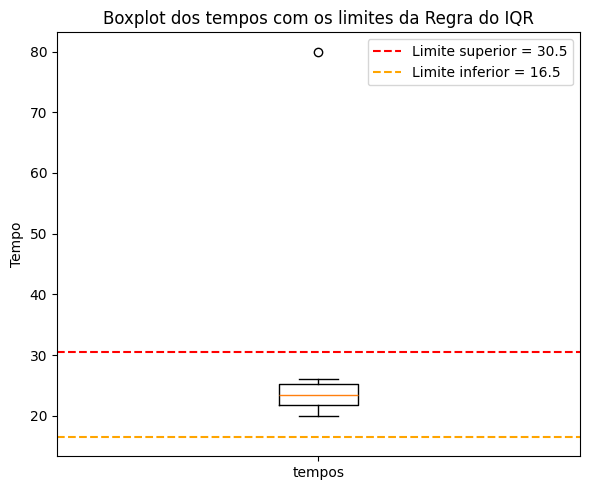

In [17]:
tempos = [20, 21, 22, 23, 24, 25, 26, 80]

Q1, Q3, IQR, limite_inferior, limite_superior, candidatos = detectar_anomalias(tempos, 1.5)

print(f'Tempos: {tempos}')
print(f'Q1: {Q1}')
print(f'Q3: {Q3}')
print(f'IQR: {IQR}')
print(f'Limite inferior: {limite_inferior}')
print(f'Limite superior: {limite_superior}')
print(f'Candidatos a outlier: {candidatos}')

fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(tempos, whis=1.5)
ax.axhline(limite_superior, color='red', linestyle='--', label=f'Limite superior = {limite_superior}')
ax.axhline(limite_inferior, color='orange', linestyle='--', label=f'Limite inferior = {limite_inferior}')
ax.set_title('Boxplot dos tempos com os limites da Regra do IQR')
ax.set_ylabel('Tempo')
ax.set_xticks([1])
ax.set_xticklabels(['tempos'])
ax.legend()
plt.tight_layout()
plt.show()

### Comparando o cálculo com o gráfico

O Matplotlib calcula as estatísticas do boxplot com a função `boxplot_stats`. Podemos consultar os valores usados no desenho e comparar com os nossos.

In [18]:
from matplotlib.cbook import boxplot_stats

estatisticas = boxplot_stats(tempos, whis=1.5)[0]
q1_grafico = estatisticas['q1']
mediana_grafico = estatisticas['med']
q3_grafico = estatisticas['q3']
bigode_inferior = estatisticas['whislo']
bigode_superior = estatisticas['whishi']
pontos_destacados = estatisticas['fliers'].tolist()

print(f'Q1 usado pelo gráfico: {q1_grafico}')
print(f'Mediana usada pelo gráfico: {mediana_grafico}')
print(f'Q3 usado pelo gráfico: {q3_grafico}')
print(f'Bigode inferior (menor valor dentro dos limites): {bigode_inferior}')
print(f'Bigode superior (maior valor dentro dos limites): {bigode_superior}')
print(f'Pontos destacados no gráfico: {pontos_destacados}')
print(f'Candidatos pela Regra do IQR: {candidatos}')
print(f'Os dois resultados coincidem? {pontos_destacados == candidatos}')

Q1 usado pelo gráfico: 21.75
Mediana usada pelo gráfico: 23.5
Q3 usado pelo gráfico: 25.25
Bigode inferior (menor valor dentro dos limites): 20
Bigode superior (maior valor dentro dos limites): 26
Pontos destacados no gráfico: [80]
Candidatos pela Regra do IQR: [80]
Os dois resultados coincidem? True


### Resposta do Exercício 11

**O valor visualmente destacado no boxplot também foi identificado pela Regra do IQR?** Sim. O ponto isolado no gráfico é o 80, exatamente o valor que ficou acima do limite superior de 30.5 no cálculo. O bigode superior para em 26, que é o maior valor dentro dos limites, e a caixa vai de 21.75 a 25.25. O gráfico e a conta contam a mesma história.

## Conclusão geral

A Regra do IQR é uma forma simples e robusta de apontar candidatos a outlier. Ela usa apenas a posição dos valores, por isso não é distorcida por valores extremos. O passo a passo é sempre o mesmo, seja em listas puras, em NumPy, em Pandas ou no boxplot.

1. Calcular Q1 e Q3.
2. Calcular o IQR.
3. Calcular os limites com o multiplicador, normalmente 1.5.
4. Apontar os valores fora dos limites como candidatos.
5. Investigar o contexto antes de corrigir, remover ou manter cada candidato.